In [5]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

<>:33: SyntaxWarning: invalid escape sequence '\P'
<>:33: SyntaxWarning: invalid escape sequence '\P'
C:\Users\nikit\AppData\Local\Temp\ipykernel_7856\4027920584.py:33: SyntaxWarning: invalid escape sequence '\P'
  img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials/opencv.png')


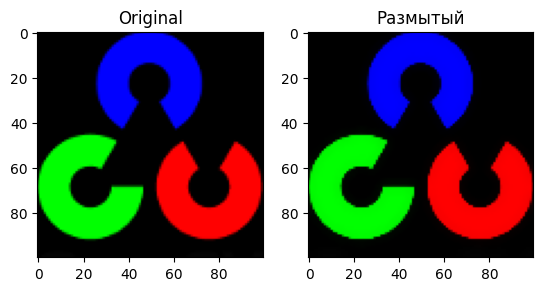

In [ ]:
"""
Сглаживание изображений

Способы:
1)cv.filter2D() - фильтрация изображений
    Операция работает следующим образом: оставьте это ядро выше пикселя, добавьте все 25 пикселей ниже этого ядра, 
    возьмите среднее значение и замените центральный пиксель новым средним значением. 
    Эта операция продолжается для всех пикселей изображения. 

2)cv.blur() или cv.boxFilter() - усреднение 
    Это делается путем свертки изображения с помощью нормализованного прямоугольного фильтра. 
    Он просто берет среднее значение всех пикселей под областью ядра и заменяет центральный элемент. 
    Это делается с помощью функции cv.blur() или cv.boxFilter(). 

3)cv.GaussianBlur() - размытие по гаусу
    В этом методе вместо коробчатого фильтра используется ядро Гаусса.
    Мы должны указать ширину и высоту ядра, которые должны быть положительными и нечетными. 
    Мы также должны указать стандартное отклонение в направлениях X и Y, sigmaX и sigmaY соответственно. 
    Если указан только sigmaX, sigmaY принимается как то же самое, что sigmaX.
    Если оба задана как нули, они вычисляются от размера ядра. 
    Размытие по Гауссу очень эффективно для удаления гауссова шума с изображения. 

4)cv.medianBlur() - срединное размытие
    Медиану всех пикселей в области ядра, и центральный элемент заменяется этим медианным значением. 
    Это очень эффективно против шума соли и перца на изображении.   
    Но при медианном размытии центральный элемент всегда заменяется на какое-то значение пикселя на изображении. 
    Это эффективно снижает уровень шума. 
    Его размер ядра должен быть положительным нечетным целым числом.

5)cv.bilateralFilter() - двусторонняя фильтрация 
    Но работа происходит медленнее по сравнению с другими фильтрами. 
    Мы уже видели, что фильтр Гаусса измеряет окрестности вокруг пикселя и находит его средневзвешенное значение по Гауссу. 
    Этот фильтр Гаусса является функцией только пространства, то есть при фильтрации учитываются соседние пиксели. 
    При этом не учитывается, имеют ли пиксели почти одинаковую интенсивность. 
    Он не учитывает, является ли пиксель краевым пикселем или нет. 
    Таким образом, он также размывает края, чего мы не хотим делать.
"""

img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials/opencv.png')
assert img is not None, "file could not be read, check with os.path.exists()"
 
'''
Способ 1
kernel = np.ones((5,5),np.float32)/25
    Второй параметр отвечает за автоматическую подстановку глубины, как у исходного рисунка
dst = cv.filter2D(img,-1,kernel)
'''
'''
Способ 2
blur = cv.blur(img,(5,5))
'''
'''
Способ 3
blur = cv.GaussianBlur(img,(5,5), 0)
    Третий параметер - 'сила' размытия, где 0 - это автоматическое размытие
    К примеру, при (5,5), то 0.5 - слабое размытие, 2.0 - сильное размытие
'''
'''
Способ 4
# plt.subplot(122),plt.imshow(blur),plt.title('Размытый') #Способ 2
'''
'''
Способ 5

'''
blur = cv.bilateralFilter(img,9,75,75)
plt.subplot(121),plt.imshow(img),plt.title('Original')
# plt.xticks([]), plt.yticks([])
# plt.subplot(122),plt.imshow(dst),plt.title('Averaging') # Способ 1
plt.subplot(122),plt.imshow(blur),plt.title('Размытый') #Способ 2
# plt.xticks([]), plt.yticks([])
plt.show()

In [10]:
import numpy as np
import cv2 as cv

img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials\photo5.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)

cv.imwrite('clahe_2.jpg',cl1)

<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
C:\Users\nikit\AppData\Local\Temp\ipykernel_7856\2863938296.py:4: SyntaxWarning: invalid escape sequence '\P'
  img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials\photo5.jpg', cv.IMREAD_GRAYSCALE)


True

<>:5: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
C:\Users\nikit\AppData\Local\Temp\ipykernel_10780\595541531.py:5: SyntaxWarning: invalid escape sequence '\P'
  img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials\photo5.jpg', cv.IMREAD_GRAYSCALE)
C:\Users\nikit\AppData\Local\Temp\ipykernel_10780\595541531.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


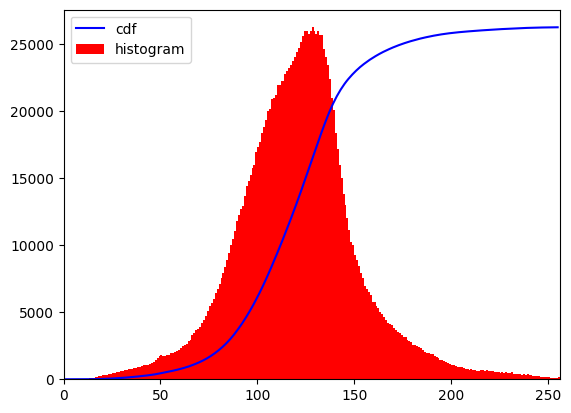

In [3]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials\photo5.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

hist,bins = np.histogram(img.flatten(),256,[0,256])

cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()